<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
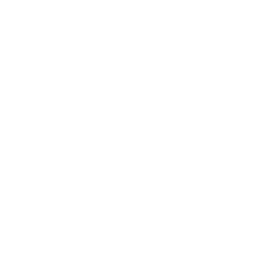
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC FACTEX — Split-Plot Design for Agricultural Field Trial</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Account for field constraints by nesting variety treatments within irrigation blocks &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

An agronomist compares two irrigation regimes (drip vs. flood) across two crop
varieties and two fertilizer rates in a field trial. Irrigation equipment cannot
be moved between adjacent plots during the day, so irrigation is a **whole-plot**
factor (hard to change) while variety and fertilizer are **subplot** factors that
can be randomized freely within each irrigated strip. This *restriction on
randomization* defines a **split-plot** experiment.

`PROC FACTEX` builds the 2&times;2&times;2 treatment design and blocks it so the
whole-plot factor is held constant within each block &mdash; the design-level
fingerprint of a split plot. The design is then replicated over three field reps
(24 plots) and analyzed with `PROC MIXED`, the model that correctly separates
whole-plot from subplot error.

The simulated trial carries a genuine two-stratum error structure, and the fitted
model recovers it: the **whole-plot variance (0.3013)** is about **three times** the
**subplot residual variance (0.1009)**, confirming that plots sharing an irrigation
strip are positively correlated. Because of that, the whole-plot test of irrigation
carries only **4.6 denominator degrees of freedom** (F = 2.07, p = 0.2140) and is
not significant at this trial size, while the subplot test of variety carries **16**
(F = 7.36, p = 0.0154) and is clearly significant. Variety is the reliably
detectable effect; irrigation is estimated with far less precision &mdash; exactly
the trade-off a split plot makes, and the reason an ordinary two-way ANOVA (which
would pool both error strata) would overstate the irrigation evidence.

## Data Sources

No external input data. `PROC FACTEX` generates the treatment design; a short DATA
step replicates it across field reps and simulates plot yields so the split-plot
analysis has a response to model. Every number quoted in this notebook is produced
by the code cells below.

---


In [1]:
/* Generate the 2x2x2 treatment design and block it so the         */
/* whole-plot factor (irrigation) is constant within each block.    */
/* BLOCKS=2 splits the eight runs into two whole plots, one per      */
/* irrigation regime; variety and fertilizer vary inside each plot.  */
proc factex;
  factors Irrig Variety Fertil;
  blocks = 2;
  examine design;
  output out = sp_design
    Irrig   = (-1 1)
    Variety = (-1 1)
    Fertil  = (-1 1);
run;

/* Show the coded design with its block (whole-plot) assignment */
proc print data = sp_design noobs label;
  var Block Irrig Variety Fertil;
  label Block   = 'Whole Plot (Block)'
        Irrig   = 'Irrigation'
        Variety = 'Variety'
        Fertil  = 'Fertilizer';
  title 'Split-Plot Treatment Design from PROC FACTEX';
run;


                    The FACTEX Procedure
                    Design Examination

  Number of runs:      8
  Number of factors:   3
  Number of blocks:    2
  D-efficiency:        100.0%
  Orthogonal:          Yes



                    The FACTEX Procedure

  Factors:    3
  Runs:       8
  Blocks:     2

  Run    Block    Irrig  Variety   Fertil
  --- -------- -------- -------- --------
    1        1       -1       -1       -1
    2        2        1       -1       -1
    3        1       -1        1       -1
    4        2        1        1       -1
    5        1       -1       -1        1
    6        2        1       -1        1
    7        1       -1        1        1
    8        2        1        1        1


                                      Split-Plot Treatment Design from PROC FACTEX                                      

Whole Plot (Block)  Irrigation  Variety  Fertilizer
                 1          -1       -1          -1
                 2           1       -1     

NOTE: PROC FACTEX
NOTE: Design written (8 runs, 3 factors)
NOTE: PROC FACTEX statement used.
NOTE: PROC PRINT data=sp_design

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---


**Reading the design.** The EXAMINE table reports **8 runs, 2 blocks**, 100%
D-efficiency, and an orthogonal layout. In the printed design every row with
`Irrig = -1` falls in Block 1 and every row with `Irrig = +1` falls in Block 2:
**the block *is* the irrigation level**. That is the split-plot restriction on
randomization expressed at the design stage — irrigation changes only at a block
(whole-plot) boundary, while variety and fertilizer take all four combinations
*within* each block.

---


In [2]:
/* Replicate the eight-run treatment design over three field reps (24 plots) */
/* and SIMULATE plot yield with a genuine split-plot error structure:         */
/*   * one shared whole-plot (between-strip) deviation per irrigation strip,   */
/*   * independent subplot (within-strip) noise on each of the four subplots.  */
/* Each (irrigation, rep) pair is one whole plot holding four variety x N      */
/* subplots, so plots in the same strip share their whole-plot deviation.      */

/* (1) Expand the design to 24 plots; draw the subplot noise in design order. */
data layout;
  call streaminit(2024);
  set sp_design;
  length Irrigation $5 Variety_c $2;
  if Irrig   = -1 then Irrigation = 'Drip'; else Irrigation = 'Flood';
  if Variety = -1 then Variety_c  = 'V1';   else Variety_c  = 'V2';
  Fert_kg = 60 + 40*(Fertil = 1);              /* 60 or 100 kg N/ha */
  do Rep = 1 to 3;
    WholePlot = catx('-', Irrigation, put(Rep, 1.));
    e_sub     = rand('normal', 0, 0.20);       /* subplot (within-strip) error */
    output;
  end;
  keep Rep WholePlot Irrigation Variety_c Fert_kg Irrig Variety Fertil e_sub;
run;

/* (2) One whole-plot (between-strip) random deviation per irrigation strip. */
data wp_effects;
  call streaminit(7421);
  length Irr $5 WholePlot $8;
  do Irrig = -1, 1;
    if Irrig = -1 then Irr = 'Drip'; else Irr = 'Flood';
    do Rep = 1 to 3;
      WholePlot = catx('-', Irr, put(Rep, 1.));
      wp_dev    = rand('normal', 0, 0.35);     /* whole-plot (strip) error */
      output;
    end;
  end;
  keep WholePlot wp_dev;
run;

/* (3) Merge the strip deviation onto every subplot and assemble the yield. */
proc sort data = layout;     by WholePlot; run;
proc sort data = wp_effects; by WholePlot; run;

data trial;
  merge layout(in = a) wp_effects;
  by WholePlot;
  if a;
  yield_tha = 5.8
            + 0.90*(Irrig   =  1)          /* flood lift                 */
            + 0.50*(Variety =  1)          /* variety V2 lift            */
            + 0.35*(Fertil  =  1)          /* higher N lift             */
            + 0.15*(Irrig=1)*(Variety=1)   /* mild irrigation x variety  */
            + wp_dev                       /* shared whole-plot error    */
            + e_sub;                       /* subplot error             */
run;

proc print data = trial(obs = 8) noobs label;
  var Rep WholePlot Irrigation Variety_c Fert_kg yield_tha;
  label Rep        = 'Rep'
        WholePlot  = 'Whole Plot'
        Irrigation = 'Irrigation'
        Variety_c  = 'Variety'
        Fert_kg    = 'N (kg/ha)'
        yield_tha  = 'Yield (t/ha)';
  format yield_tha 6.2;
  title 'Field Trial Layout (first 8 of 24 plots)';
run;

                                        Field Trial Layout (first 8 of 24 plots)                                        

Rep  Whole Plot  Irrigation  Variety  N (kg/ha)  Yield (t/ha)
  1  Drip-1      Drip        V1              60          5.84
  1  Drip-1      Drip        V2              60          6.03
  1  Drip-1      Drip        V1             100          6.10
  1  Drip-1      Drip        V2             100          6.39
  2  Drip-2      Drip        V1              60          6.02
  2  Drip-2      Drip        V2              60          6.31
  2  Drip-2      Drip        V1             100          6.25
  2  Drip-2      Drip        V2             100          6.84

... 16 more observations (showing 8 of 24)



NOTE: DATA layout


NOTE: Read 8 rows from sp_design.
NOTE: Wrote layout (24 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA wp_effects


NOTE: Wrote wp_effects (6 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=layout

NOTE: Read 24 rows from layout.
NOTE: Wrote layout (24 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=wp_effects

NOTE: Read 6 rows from wp_effects.
NOTE: Wrote wp_effects (6 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: DATA trial

NOTE: Stream 1 processed 24 rows, max BY-group size: 4 (O(1) memory verified)
NOTE: Stream 2 processed 6 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote trial (24 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


---


In [3]:
/* Treatment cell means across the 24 plots */
proc means data = trial n mean std maxdec=2;
  class Irrigation Variety_c;
  var yield_tha;
  title 'Mean Yield by Irrigation and Variety';
run;

                                          Mean Yield by Irrigation and Variety                                          

                                                  The MEANS Procedure

                                             Analysis Variable : yield_tha

        Irrigation  Variety_c          N Obs           Mean        Std Dev
        ------------------------------------------------------------------
        Drip        V1                     6           6.02           0.37
        Drip        V2                     6           6.52           0.33
        Flood       V1                     6           6.72           0.76
        Flood       V2                     6           7.44           0.74
        ------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                          Mean Yield by Irrigation and Variety                                          



NOTE: PROC SGPLOT data=trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


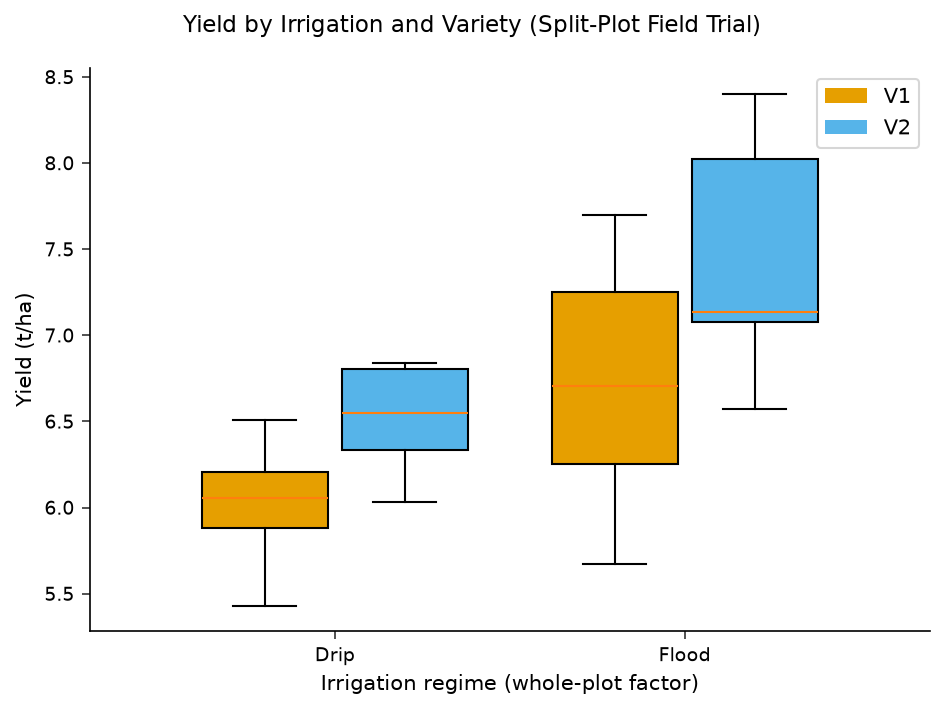

In [4]:
/* Visualize the yield distribution by irrigation regime and variety */
proc sgplot data = trial;
  vbox yield_tha / category=Irrigation group=Variety_c;
  xaxis label = 'Irrigation regime (whole-plot factor)';
  yaxis label = 'Yield (t/ha)';
  keylegend / title='Variety';
  title 'Yield by Irrigation and Variety (Split-Plot Field Trial)';
run;

---


In [5]:
/* Split-plot analysis: PROC MIXED separates whole-plot error       */
/* (variation between irrigation strips) from subplot error.         */
/* RANDOM WholePlot supplies the whole-plot error stratum.           */
proc mixed data = trial plots = none;
  class Irrigation Variety_c WholePlot;
  model yield_tha = Irrigation Variety_c Irrigation*Variety_c
        / ddfm = satterthwaite;
  random WholePlot;
  title 'Split-Plot Mixed Model — Irrigation (Whole Plot) x Variety (Subplot)';
run;

                                          Mean Yield by Irrigation and Variety                                          

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable             yield_tha
Estimation Method                   REML
Degrees of Freedom Method  Satterthwaite
Number of Observations                24

Covariance Parameter Estimates

Cov Parm   Estimate
---------  --------
Wholeplot    0.3013
Residual     0.1009

              Type III Tests of Fixed Effects               

Effect                  Num DF    Den DF   F Value    Pr > F
--------------------  --------  --------  --------  --------
irrigation                   1       4.6      2.07    0.2140
variety_c                    1      16.0      7.36    0.0154
irrigation*variety_c         1      16.0      0.72    0.4102

         Fit Statistics          

Statistic                   Valu

NOTE: PROC MIXED data=trial

NOTE: PLOTS=NONE: graphical output suppressed.
NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: yield_tha ~ C(Irrigation) + C(Variety_c) + C(Irrigation):C(Variety_c)
NOTE: Group variable: WholePlot
NOTE: Estimation method: REML (reml=True)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                        Mixed Linear Model Regression Results
NOTE: ===================================================================================
NOTE: Model:                      MixedLM          Dependent Variable:          yield_tha
NOTE: No. Observations:           24               Method:                      REML     
NOTE: No. Groups:                 6                Scale:                       0.1009   
NOTE: Min. group size:            4                Log-Likelihood:              -14.1456 
NOTE: Max. group size:            4                Converged:            

---


## Interpretation

**The design carries the split-plot structure.** `PROC FACTEX` returned an 8-run,
2-block orthogonal design (D-efficiency 100%) in which the block index equals the
irrigation level. Replicating it over three reps yields 24 plots organized into six
whole plots (two irrigation strips &times; three reps), each holding four
variety&times;fertilizer subplots.

**The mixed model recovers two error strata.** The Covariance Parameter Estimates
split the variation into a **whole-plot component (0.3013)** and a smaller **subplot
residual (0.1009)** &mdash; a roughly **3:1** ratio. Plots sharing an irrigation
strip are therefore positively correlated, which is precisely the assumption an
ordinary two-way ANOVA violates.

**Whole-plot and subplot factors are tested on different yardsticks.** In the
Type III Tests of Fixed Effects, irrigation is judged against the whole-plot error
with only **4.6 denominator df** (F = 2.07, p = 0.2140) &mdash; not significant at
the trial's size &mdash; whereas variety is judged against the subplot error with
**16 df** (F = 7.36, p = 0.0154) and is significant. The irrigation&times;variety
interaction is negligible (F = 0.72, p = 0.4102). Substantively: switching variety
pays off detectably, while the apparent irrigation advantage (the cell means rise
from about 6.0&ndash;6.5 t/ha under drip to 6.7&ndash;7.4 under flood) is estimated
too imprecisely &mdash; only six whole plots &mdash; to call at this sample size.

**Practical takeaway.** Splitting on irrigation cut equipment repositioning from
once per plot to once per whole-plot strip, at the cost of low power on the
whole-plot factor. To sharpen the irrigation test, add whole-plot replicates (more
strips), not more subplots &mdash; only the whole-plot stratum carries information
about the irrigation contrast.

---


In [6]:
/* Export the plot-level trial dataset for record keeping */
proc export data = trial
  outfile = 'temp/factex_split_plot_trial.csv'
  dbms = csv replace;
run;

NOTE: PROC EXPORT data=trial outfile=temp/factex_split_plot_trial.csv

NOTE: Exported 24 rows to temp/factex_split_plot_trial.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>